# 1. Preparing Python development environment

The course materials and assignments use common scientific and geospatial libraries such as *pandas*, *xarray*, *rioxarray*, *geopandas*, *matplotlib*, *cartopy*, and *scikit-learn*.

Depending on your setup, you can install the required libraries using either **pip**, **conda**, or **Google Colab**.

Most of these are in the **requirements.txt** file and can be installed 

## Using pip

Install all packages listed in requirements.txt:
```bash
pip install -r requirements.txt
```

Install a single package:
```bash
pip install xarray
```

## Using conda

Setup and create an environment from environment.yml:

```bash
conda env create -f environment.yml
conda activate climate-course
```

## Using Google Colab

Install packages in a notebook cell:
```bash
!pip install xarray rioxarray geopandas cartopy cdsapi
```

# 2. NASA GISTEMP

NASA GISTEMP provides estimates of global surface temperature anomalies based on:
- Land-based meteorological stations
- Sea surface temperature measurements
- Spatial interpolation to account for incomplete coverage

The dataset reports temperature anomalies, not absolute temperatures.

GISTEMP provides:
- Monthly and annual data
- Global mean temperature anomalies
- Gridded temperature anomaly maps
- Coverage extending back to the late 19th century (~1880)

## Accessing the dataset

NASA GISTEM provides various datasets for download directly at https://data.giss.nasa.gov/gistemp/

These files are available in both CSV and NetCDF format. 

For example, we can find the **global mean temperature anomaly dataset** by looking into *Global-mean monthly, seasonal, and annual means, 1880-present, updated through most recent month*

We can download the CSV file or access the dataset directly using **pandas** from the link:

In [1]:
import pandas as pd

url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

df_raw = pd.read_csv(url, skiprows=1)

df_raw.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-.09,-.16,-.10,-.21,-.18,-.10,-.14,-.23,-.22,-.19,-.17,***,***,-.12,-.17,-.20
1,1881,-0.20,-0.15,.02,.04,.07,-.19,.01,-.04,-.15,-.21,-.18,-.07,-.09,-.10,-.18,.04,-.07,-.18
2,1882,0.16,0.14,.04,-.16,-.14,-.23,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.09,-.16,-.18
3,1883,-0.29,-0.36,-.12,-.18,-.18,-.07,-.08,-.14,-.22,-.11,-.24,-.12,-.18,-.20,-.34,-.16,-.10,-.19
4,1884,-0.13,-0.08,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.33,-.31,-.28,-.27,-.11,-.37,-.31,-.28


For working with NetCDF files, you might need to install **xarray** and **netCDF4** libraries.

# 3. ERA5 Climate Reanalysis Datasets

**ERA5 Climate Reanalysis Dataset**

ERA5 is a global climate reanalysis dataset produced by the **European Centre for Medium-Range Weather Forecasts (ECMWF)** through the **Copernicus Climate Change Service (C3S)**.

## How to Download ERA5 Data

### Option 1 — Web Interface

ERA5 datasets can be downloaded from the Copernicus Climate Data Store (CDS): https://cds.climate.copernicus.eu/

Steps:

1. Create a free account
2. Go to the Climate Data Store
3. Select a dataset (e.g. ERA5 hourly data)
4. Choose variables, region, and time period
5. Download the dataset in NetCDF format

Example dataset used for lesson *2. Climate Hazards and Emerging Climate Change Hotspots*:
> ERA5 monthly averaged data on single levels

The data selection window looks like this: 

<img src="era5-1.png"  width="600">

At the bottoms of data selection interface, there is **Corresponding API request** section which contains the script for request that can be used for:

### Option 2 — API Download

ERA5 has pretty strict limits on dataset size download limit; sometimes a script is necessary to obtain data covering several years or larger areas. Be warned that sometimes, the download times can be very long. 

First install the CDS client:
> pip install cdsapi

Then configure the API key from the Copernicus account.

The API key must be saved in a configuration file called: 
> .cdsapirc

This file must be placed in your **home directory**.

The file should contain:

    url: https://cds.climate.copernicus.eu/api
    key: <your-user-id>:<your-api-key>

In Google Colab you must create the file manually inside the environment.

    !echo "url: https://cds.climate.copernicus.eu/api
    key: YOUR_UID:YOUR_API_KEY" > ~/.cdsapirc

Example Python request(this script can also be produced in the web UI when you select all download options):

In [2]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': '2022',
        'month': '07',
        'time': '00:00',
        'format': 'netcdf'
    },
    'era5_temperature.nc')

2026-03-13 17:41:09,200 INFO Request ID is b373c44d-4e0c-4f1f-8cb8-047aee29375a
2026-03-13 17:41:09,407 INFO status has been updated to accepted
2026-03-13 17:41:18,929 INFO status has been updated to running
2026-03-13 17:41:24,148 INFO status has been updated to successful


48825ec7a8e634ab87a3766188ece1d5.nc:   0%|          | 0.00/1.33M [00:00<?, ?B/s]

'era5_temperature.nc'

In [3]:
# Dataset looks like this:
import xarray as xr

ds = xr.open_dataset("era5_temperature.nc")

ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2022-07-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-13T15:41 GRIB to CDM+CF via cfgrib-0.9.1...

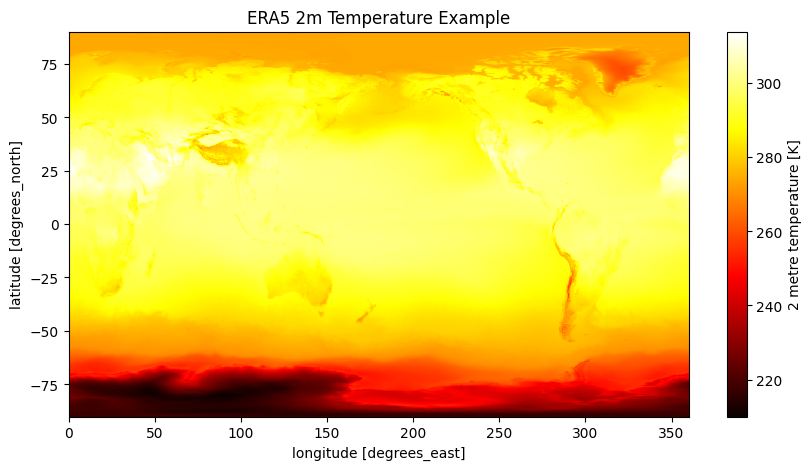

In [4]:
# Example: Plot a Hazard Map
import matplotlib.pyplot as plt

temp = ds['t2m'].isel(valid_time=0)

plt.figure(figsize=(10, 5))
temp.plot(cmap="hot")
plt.title("ERA5 2m Temperature Example")
plt.show()

## Useful script for downloading ERA5 data over multiple years

ERA5 dataset has size limit and the download time can vary, depending to the access overload at a time, downloading data for one year can take between 2 minutes and 2 hours!! If you need to donwload data over multiple years, you want to make multiple sepparate requests and this script could be useful, looping through multiple years and showing timestamps:

In [ ]:
import cdsapi
from datetime import datetime
import time

c = cdsapi.Client()

years = ["2020", "2021", "2022"]
months = ["06", "07", "08"]

for year in years:
    for month in months:
        output_file = f"era5_temperature_{year}_{month}.nc"
        
        start_time = time.time()
        print("=" * 60)
        print(f"Starting download for {year}-{month}")
        print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        c.retrieve(
            "reanalysis-era5-single-levels-monthly-means",
            {
                "product_type": "monthly_averaged_reanalysis",
                "variable": "2m_temperature",
                "year": year,
                "month": month,
                "time": "00:00",
                "format": "netcdf"
            },
            output_file
        )
        
        elapsed = time.time() - start_time
        print(f"Finished download for {year}-{month}")
        print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Elapsed time: {elapsed:.2f} seconds")
        print("=" * 60)

## ERA5 reanalysis daily maximum temperature data

You might need this dataset for the assignment on lesson 3, here is the script that could be used to download it with a selection of Central Europe area:

In [5]:
import cdsapi

client = cdsapi.Client()

client.retrieve(
    "derived-era5-single-levels-daily-statistics",
    {
        "product_type": "reanalysis",
        "variable": "2m_temperature",
        "year": "2024",
        "month": ["05", "06", "07", "08", "09"],
        "day": [f"{d:02d}" for d in range(1, 32)],
        "daily_statistic": "daily_maximum",
        "time_zone": "utc+00:00",
        "frequency": "6_hourly",
        "area": [55, 5, 47, 20],  # North, West, South, East, Central Europe Bounding Box
        "format": "netcdf",
    },
    "era5_tmax_central_europe_2024.nc"
)

2026-03-13 17:50:26,457 INFO Request ID is 26d2d8d8-597c-41d9-b5a3-9806f1749832
2026-03-13 17:50:26,613 INFO status has been updated to accepted
2026-03-13 17:51:01,887 INFO status has been updated to successful


d40a0df1a61be47d4ef7c91b7b8de805.nc:   0%|          | 0.00/528k [00:00<?, ?B/s]

'era5_tmax_central_europe_2024.nc'

In [6]:
#  Loading the dataset and prepare for plotting
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = xr.open_dataset("era5_tmax_central_europe_2024.nc")
print(ds)
print(ds["t2m"].dims)

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 153, latitude: 33, longitude: 61)
Coordinates:
    number      int64 8B ...
  * latitude    (latitude) float64 264B 55.0 54.75 54.5 ... 47.5 47.25 47.0
  * longitude   (longitude) float64 488B 5.0 5.25 5.5 5.75 ... 19.5 19.75 20.0
  * valid_time  (valid_time) datetime64[ns] 1kB 2024-05-01 ... 2024-09-30
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-11T04:41 GRIB to CDM+CF via cfgrib-0.9.1...
('valid_time', 'latitude', 'longitude')


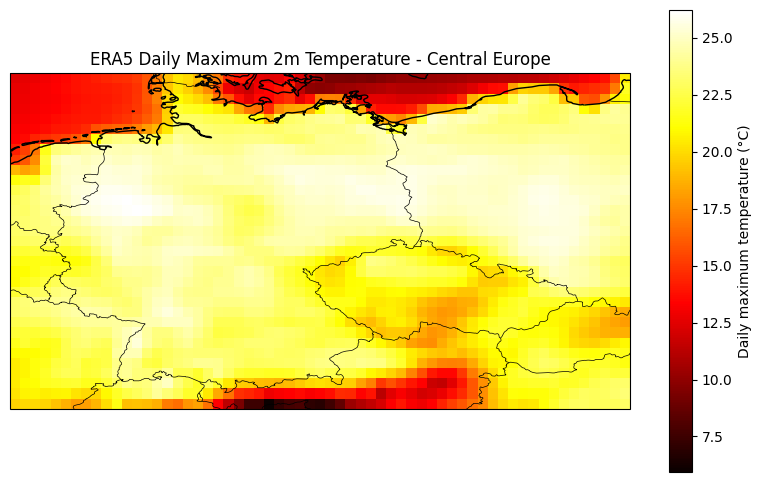

In [7]:
#  Example plot using cartopy, which can be used to show geogrpahical borders
tmax = ds["t2m"].isel(valid_time=0) - 273.15  # Kelvin to Celsius

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

tmax.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="hot",
    cbar_kwargs={"label": "Daily maximum temperature (°C)"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("ERA5 Daily Maximum 2m Temperature - Central Europe")
plt.show()

# 4. Exposure Dataset: GHS-POP (Population)

To estimate climate exposure, we use the Global Human Settlement Population dataset (GHS-POP) developed by the European Commission's Joint Research Centre (JRC).

The dataset provides spatial population estimates derived from census data combined with satellite imagery and settlement maps.

Key features:
- Global population distribution
- Spatial resolution up to 1 km
 -Multiple years available
- Provided as GeoTIFF raster files

Dataset source:

>https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php

When you click **Download the GHS-POP dataset**, you will see a setup with a few options to select:
- **Product**: GHS-POP, representing the spatial distribution of residential population (number of people per grid cell)
- **Epoch**: 2020, the reference year for the population estimate, providing a recent representation of global population distribution.
- **Resolution**: 1km, each grid cell represents approximately one square kilometer, offering a good balance between spatial detail and computational efficiency.
- **Coord. system**: Mollweide projection, an equal-area projection used to ensure consistent representation of population density across the globe. The GHS-POP dataset is distributed using the **Mollweide equal-area projection**. This projection **preserves area relationships**, which is particularly important for population datasets where each grid cell represents the number of people within a specific land area. Using an equal-area projection helps ensure that population density calculations remain consistent across the globe.

**Note**: ERA5 climate data is provided on a latitude–longitude grid using the WGS84 coordinate system. To combine population data with climate variables (such as temperature or precipitation), both datasets must use the same coordinate reference system and grid structure. Therefore, the GHS-POP dataset is reprojected from the Mollweide projection to WGS84, allowing it to be aligned with the ERA5 climate grid.


**Loading the GHS-POP raster**

The GHS-POP dataset is distributed as a **GeoTIFF raster**, so we use **rioxarray** to load it in Python.

rioxarray extends xarray with geospatial raster functionality, allowing us to:
- inspect the coordinate reference system (CRS)
- crop the raster to a study region
- reproject it to another CRS
- align it with climate datasets such as ERA5

Because the global population raster is very large, we also load it with chunks. This enables lazy loading with dask, so the full dataset is not read into memory at once.

In [8]:
# Example accessing the dataset first 
import rioxarray as rxr

pop_path = "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif"

pop = rxr.open_rasterio(
    pop_path,
    masked=True,
    chunks={"x": 2048, "y": 2048}   # tweak if needed (1024 also fine)
).squeeze("band")

print(pop)
print("CRS:", pop.rio.crs)
print("Resolution:", pop.rio.resolution())

<xarray.DataArray (y: 18000, x: 36082)> Size: 5GB
dask.array<getitem, shape=(18000, 36082), dtype=float64, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 289kB -1.804e+07 -1.804e+07 ... 1.804e+07 1.804e+07
  * y            (y) float64 144kB 9e+06 8.998e+06 ... -8.998e+06 -9e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        338726.57110608
    STATISTICS_MEAN:           56.785121486231
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         679.48856478339
    STATISTICS_VALID_PERCENT:  21.26
    scale_factor:              1.0
    add_offset:                0.0
CRS: ESRI:54009
Resolution: (1000.0, -1000.0)


### Clip the raster to Central Europe

Since the original raster is global and very large, we first crop it to the study area.

The GHS-POP raster is stored in the Mollweide projection, while our bounding box is easier to define in WGS84 latitude/longitude, so we first transform the bounding box coordinates.

In [9]:
import pyproj
import numpy as np

# Central Europe bounding box in WGS84
north, west, south, east = 55, 5, 47, 20

# Transform bounding box from WGS84 to the raster CRS (Mollweide)
transformer = pyproj.Transformer.from_crs("EPSG:4326", pop.rio.crs, always_xy=True)

xs, ys = transformer.transform(
    [west, east, west, east],
    [south, south, north, north]
)

minx, maxx = float(np.min(xs)), float(np.max(xs))
miny, maxy = float(np.min(ys)), float(np.max(ys))

print("Clipping bounds in Mollweide:")
print(minx, miny, maxx, maxy)

# Clip raster
pop_ce = pop.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

print(pop_ce)

Clipping bounds in Mollweide:
353871.2689345557 5555784.3927511 1579099.9618520206 6386579.968095269
<xarray.DataArray (y: 832, x: 1227)> Size: 8MB
dask.array<getitem, shape=(832, 1227), dtype=float64, chunksize=(832, 1189), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 10kB 3.535e+05 3.545e+05 ... 1.578e+06 1.58e+06
  * y            (y) float64 7kB 6.386e+06 6.386e+06 ... 5.556e+06 5.556e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        338726.57110608
    STATISTICS_MEAN:           56.785121486231
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         679.48856478339
    STATISTICS_VALID_PERCENT:  21.26
    scale_factor:              1.0
    add_offset:                0.0


In [10]:
# Reproject to WGS84
pop_ce_wgs84 = pop_ce.rio.reproject("EPSG:4326")

print("Reprojected CRS:", pop_ce_wgs84.rio.crs)
print("Shape:", pop_ce_wgs84.shape)
print("Resolution:", pop_ce_wgs84.rio.resolution())

Reprojected CRS: EPSG:4326
Shape: (698, 1555)
Resolution: (0.01148379681204056, -0.01148379681204056)


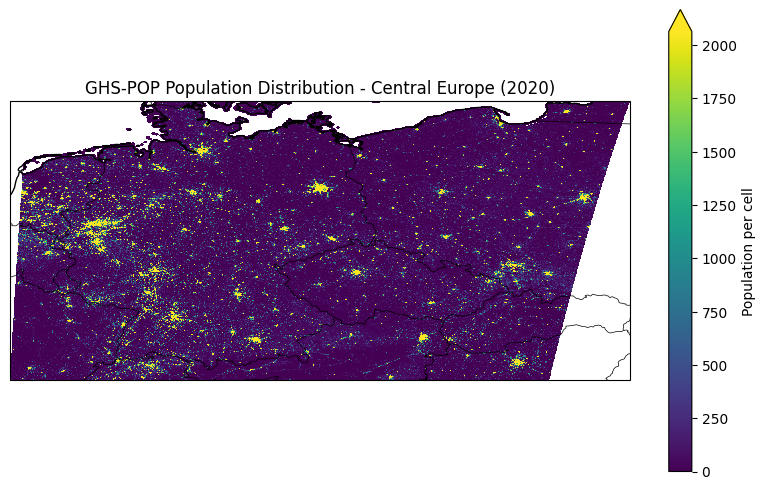

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(10,6))

ax = plt.axes(projection=ccrs.PlateCarree())

pop_ce_wgs84.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    robust=True,
    cbar_kwargs={"label": "Population per cell"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.set_title("GHS-POP Population Distribution - Central Europe (2020)")

plt.show()

# 5. Vulnerability Dataset: World Bank Indicators

Climate vulnerability is strongly influenced by social and economic conditions.

In this exercise we use indicators from the **World Bank Open Data platform**, which provides global socio-economic statistics.

Website:
>https://data.worldbank.org

Example indicators:
| Indicator                     | Code              |
| ----------------------------- | ----------------- |
| Population ages 65+ (%)       | SP.POP.65UP.TO.ZS |
| GDP per capita                | NY.GDP.PCAP.CD    |
| Health expenditure per capita | SH.XPD.CHEX.PC.CD |

These correspond to:
- **Sensitivity** → elderly population share
- **Adaptive capacity** → economic resources
- **Response capacity** → health system investment

We could use the API(https://data360.worldbank.org/en/api) to download and load the data from those datasets.

The request URL looks like this:
> https://api.worldbank.org/v2/country/all/indicator/<INDICATOR_CODE>?format=json

Example:
> https://api.worldbank.org/v2/country/all/indicator/SP.POP.65UP.TO.ZS

The following is a robust code to download a dataset including the 3 Socioeconomic Vulnerability Indicators

In [12]:
# Step 1: Download and load the data from WorldBank API
import requests
import pandas as pd

def fetch_indicator(indicator_code, year="2024"):
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/"
        f"{indicator_code}?format=json&per_page=20000"
    )
    r = requests.get(url)
    js = r.json()

    # Handle API errors
    if not isinstance(js, list) or len(js) < 2:
        raise RuntimeError(f"World Bank API error for {indicator_code}: {js}")

    data = js[1]
    df = pd.json_normalize(data)

    # Keep chosen year + valid values
    df = df[df["date"] == str(year)]
    df = df[df["value"].notna()]

    # IMPORTANT: use ISO3 column
    df["countryiso3code"] = df["countryiso3code"].astype(str).str.strip().str.upper()

    # Keep only real ISO3 country codes (drops aggregates)
    df = df[df["countryiso3code"].str.fullmatch(r"[A-Z]{3}", na=False)]

    return df[["countryiso3code", "value"]].rename(columns={"value": indicator_code})

elderly = fetch_indicator("SP.POP.65UP.TO.ZS", year="2020")
gdp     = fetch_indicator("NY.GDP.PCAP.CD", year="2020")
health  = fetch_indicator("SH.XPD.CHEX.PC.CD", year="2020")

df = elderly.merge(gdp, on="countryiso3code", how="inner").merge(health, on="countryiso3code", how="inner")

df = df.rename(columns={
    "countryiso3code": "iso3",
    "SP.POP.65UP.TO.ZS": "elderly_pct",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SH.XPD.CHEX.PC.CD": "health_exp"
})

print(df.shape)
df.head()

(234, 4)


,iso3,elderly_pct,gdp_per_capita,health_exp
0,AFE,3.192169,1351.591669,81.446140
1,AFW,2.916504,2030.861659,64.624190
2,ARB,4.270911,5739.412836,327.069626
3,CSS,8.919143,11957.223223,796.157980
4,CEB,19.154477,16581.352612,1187.604626


# 6. Obtaining Landsat Satellite Data

The Landsat program, operated by **NASA and the US Geological Survey (USGS)**, provides one of the longest continuous records of Earth observation. Landsat satellites capture multispectral images of the Earth's surface that can be used to analyze land cover, vegetation, water resources, and urban environments.

For urban climate analysis, Landsat imagery is particularly useful because of its **high spatial resolution (30 m)**, which allows detailed analysis of individual neighborhoods within cities.

**Key characteristics:**
| Feature             | Value    |
| ------------------- | -------- |
| Spatial resolution  | ~30 m    |
| Temporal resolution | ~16 days |
| Coverage            | Global   |
| Data format         | GeoTIFF  |

Typical Landsat scenes contain multiple spectral bands, for example:
- visible light bands
- near-infrared bands
- shortwave infrared bands
- thermal infrared bands

These bands allow researchers to derive indicators such as:
- land surface temperature
- vegetation indices (NDVI)
- built-up area detectio

## Example: Obtaining Landsat 8/9 Collection 2 Level-2 for Berlin area
For this example, we are going to look into Landsat 8/9 Collection 2 Level-2 and focus on the Berlin area.

### Landsat 8/9 Collection 2 Level-2 Data

The **Landsat program**, operated by NASA and the US Geological Survey (USGS), provides long-term satellite observations of Earth's surface. Landsat satellites capture multispectral images that allow analysis of land cover, vegetation, water resources, and urban environments.

For this exercise, we use **Landsat 8/9 Collection 2 Level-2 data**, which provides science-ready products derived from the raw satellite observations.

**Landsat data processing levels**
| Level        | Description                                          |
| ------------ | ---------------------------------------------------- |
| Level-1      | Raw satellite measurements with geometric correction |
| Level-2      | Surface reflectance and surface temperature products |
| Collection 2 | Improved calibration and geolocation accuracy        |

**What Level-2 data contains**

Level-2 products include:

**Surface Reflectance (SR)**
Reflectance values corrected for atmospheric effects.

Example bands:
- SR_B2 – blue
- SR_B3 – green
- SR_B4 – red
- SR_B5 – near-infrared

These bands are commonly used to compute indices such as:
- NDVI (vegetation index)
- land cover classification

### Accessing the data

The dataset can be accessed by going to https://earthexplorer.usgs.gov/ and start by creating an account.

After that, start selectings on this menu: 

<img src="usgs-1.png"  width="200">

There, we select :
- "Use Map" and select the Berlin area by introducing the bounding box coordinates: (13.09, 52.33, 13.76, 52.65)
- Date range 6/01/2025 to 08/31/2025
- Cloud Cover: 0% - 10% and ignore uncertain

On the DataSet Page, navigate to select: 
> Landsat Collection 2 Level-2 -> Landsat 8-9 OLI/TIRS C2 L2

<img src="usgs-2.png"  width="600">

When clicking "Results", it will show multiple scans around the area selected for Berlin. You want to find one that when clicking on *show footprint*, it fully contains the selected area and click "Download All Files Now" on the *Level-2 Surface Temperature Bands* which can be used for:
- Surface temperature analysis
- Urban Heat Island
- Thermal studies

<img src="usgs-3.png"  width="600">

The download will contain 3 .TIF files that should be placed in *Landsat 8-9 C2 L2* folder in order to run the code and the files are:
- "LC09_L2SP_193023_20250819_20250821_02_T1_QA_RADSAT.TIF": Radiometric saturation flags. Helpful quality info, not required for your first heatmap.
- "LC09_L2SP_193023_20250819_20250821_02_T1_ST_ATRAN.TIF" Atmospheric transmittance term used in the LST retrieval. Useful for diagnostics, not required for this exercise.
- "LC09_L2SP_193023_20250819_20250821_02_T1_ST_B10.TIF": The one we need. This is the **Surface Temperature band** (scaled integers). We’ll convert it to Kelvin / Celsius.

*Optional*: go to Select files and chose to download the "QA_PIXEL.tif" file which would be needed to handle weird cold/hot patches.

For the **first step**, we start by inspecting the data inside "LC09_L2SP_193023_20250819_20250821_02_T1_QA_RADSAT.TIF"


In [13]:
import rasterio
from rasterio.plot import show
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt

st_path = "Landsat 8-9 C2 L2/LC09_L2SP_193023_20250819_20250821_02_T1_ST_B10.TIF"

# Inspect data
with rasterio.open(st_path) as src:
    print("CRS:", src.crs)
    print("Resolution (x,y):", src.res)
    print("Bounds:", src.bounds)
    print("Shape (h,w):", (src.height, src.width))
    print("Dtype:", src.dtypes[0])
    print("Nodata:", src.nodata)
    print("Tags (first few):", list(src.tags().items())[:10])

CRS: EPSG:32633
Resolution (x,y): (30.0, 30.0)
Bounds: BoundingBox(left=276285.0, bottom=5762385.0, right=517815.0, top=6006315.0)
Shape (h,w): (8131, 8051)
Dtype: uint16
Nodata: 0.0
Tags (first few): [('AREA_OR_POINT', 'Point')]


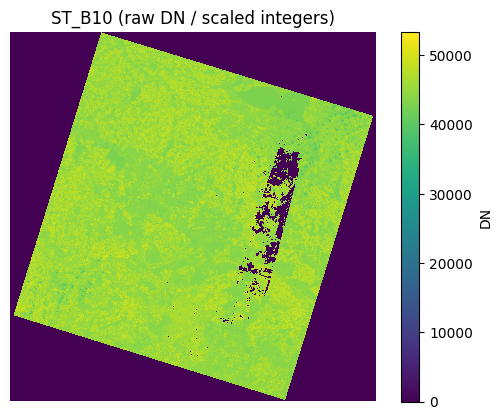

In [14]:
# Quick plot of the full tile
with rasterio.open(st_path) as src:
    st_dn = src.read(1)

plt.figure()
plt.imshow(st_dn, interpolation="nearest")
plt.title("ST_B10 (raw DN / scaled integers)")
plt.axis("off")
plt.colorbar(label="DN")
plt.show()

### Convert ST_B10 to temperature (Kelvin → Celsius)

Common Landsat C2 L2 scaling for surface temperature is:
$$T(K)=DN×0.00341802+149.0$$
$$T(°C)=T(K)−273.15$$

But to be robust, we first try to read scale/offset from tags (if present), and if not, we fall back.

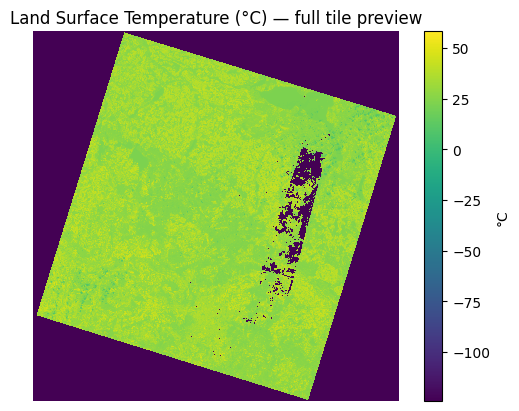

In [15]:
def st_dn_to_celsius(st_dn, scale=None, offset=None):
    # Fallback defaults commonly used for Landsat C2 L2 ST
    if scale is None:
        scale = 0.00341802
    if offset is None:
        offset = 149.0
    temp_k = st_dn * scale + offset
    temp_c = temp_k - 273.15
    return temp_c

with rasterio.open(st_path) as src:
    st_dn = src.read(1).astype("float32")
    tags = src.tags()

# Optional: try to pull scale/offset if tags contain them
scale = None
offset = None
for k, v in tags.items():
    if "scale" in k.lower():
        try: scale = float(v)
        except: pass
    if "offset" in k.lower() or "add" in k.lower():
        try: offset = float(v)
        except: pass

st_c = st_dn_to_celsius(st_dn, scale=scale, offset=offset)

plt.figure()
plt.imshow(st_c, interpolation="nearest")
plt.title("Land Surface Temperature (°C) — full tile preview")
plt.axis("off")
plt.colorbar(label="°C")
plt.show()

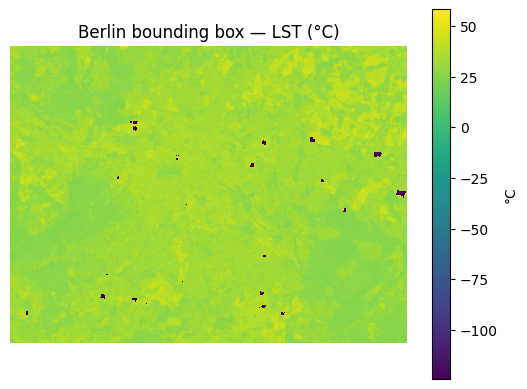

In [16]:
# Crop to Berlin bounding box
from pyproj import Transformer

bbox_lonlat = (13.09, 52.33, 13.76, 52.65)  # (minx, miny, maxx, maxy)

with rasterio.open(st_path) as src:
    raster_crs = src.crs
    transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)

    minx, miny = transformer.transform(bbox_lonlat[0], bbox_lonlat[1])
    maxx, maxy = transformer.transform(bbox_lonlat[2], bbox_lonlat[3])

    window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    st_dn_crop = src.read(1, window=window).astype("float32")

st_c_crop = st_dn_to_celsius(st_dn_crop, scale=scale, offset=offset)

plt.figure()
plt.imshow(st_c_crop, interpolation="nearest")
plt.title("Berlin bounding box — LST (°C)")
plt.axis("off")
plt.colorbar(label="°C")
plt.show()

# 7. Obtaining MODIS data

**Landsat has two important limitations**:
- Low temporal frequency (≈16-day revisit time)
- Limited long-term time series continuity

To study how urban heat islands evolve over time, we need satellite observations that provide **frequent measurements over many years**.

For this purpose, you could use **MODIS (Moderate Resolution Imaging Spectroradiometer)**.

## MODIS Overview

MODIS is an Earth-observing instrument onboard NASA satellites:
- **Terra** (launched 1999)
- **Aqua** (launched 2002)

MODIS provides **global measurements every 1–2 days**, making it ideal for monitoring long-term environmental changes.

Key characteristics:
| Feature             | Landsat             | MODIS                       |
| ------------------- | ------------------- | --------------------------- |
| Spatial resolution  | ~30 m               | ~1 km                       |
| Temporal resolution | 16 days             | Daily                       |
| Coverage            | Local scenes        | Global                      |
| Best use            | Local city analysis | Regional & temporal studies |


Thus:
- Landsat → spatial detail
- MODIS → temporal monitoring

Combining both datasets allows scientists to study urban climate across space and time.

## MODIS Land Surface Temperature (LST)
MODIS provides global **Land Surface Temperature (LST)** products derived from thermal infrared observations.

The LST is retrieved using atmospheric correction algorithms applied to thermal radiation measured by the sensor.

The surface temperature is related to emitted thermal radiation through **Planck's Law**:
$$
L(λ,T)= \frac{2hc^2}{λ^5}\frac{1}{e^{\frac{hc}{λkt}} - 1}
$$

Where:
- $L(λ,T)$ = spectral radiance
- $T$ = surface temperature
- $h$ = Planck constant
- $c$ = speed of light
- $k$ = Boltzmann constant
- $λ$ = wavelength

Satellite algorithms invert this relationship to estimate surface temperature.


## MODIS LST Products

Common MODIS datasets used in climate studies include:
| Product | Description            |
| ------- | ---------------------- |
| MOD11A2 | 8-day average LST      |
| MYD11A2 | Aqua equivalent        |
| MOD11C3 | Monthly global LST     |
| MOD21A2 | Improved LST retrieval |

Typical spatial resolution:
$$1 km×1 km$$

Although this is much coarser than Landsat, it provides a consistent global time series spanning more than 20 years.

### Dataset selection: MODIS MOD11A2

 MODIS MOD11A2, can be obtained from https://ladsweb.modaps.eosdis.nasa.gov/ where you have to start by creating an account. 

After that, go into the "Find Data" menu and search for "MODIS MOD11A2" product, select the time June 1st 2025 - August 31st 2025. For the location, we select the same bounding box as we did previously: (52.33, 13.09, 52.65, 13.76). 

<img src="modis-1.png"  width="600">

For the next step, it would show a list with 13 files looking like this: 

"MOD11A2.A2025145.h18v03.061.2025154055922.hdf
MOD11A2.A2025153.h18v03.061.2025163044849.hdf
MOD11A2.A2025161.h18v03.061.2025171220519.hdf
MOD11A2.A2025169.h18v03.061.2025178160651.hdf
MOD11A2.A2025177.h18v03.061.2025189033331.hdf
MOD11A2.A2025185.h18v03.061.2025195164349.hdf
MOD11A2.A2025193.h18v03.061.2025206025549.hdf
MOD11A2.A2025201.h18v03.061.2025210041451.hdf
MOD11A2.A2025209.h18v03.061.2025218041705.hdf
MOD11A2.A2025217.h18v03.061.2025227052038.hdf
MOD11A2.A2025225.h18v03.061.2025235063224.hdf
MOD11A2.A2025233.h18v03.061.2025245205708.hdf
MOD11A2.A2025241.h18v03.061.2025252235742.hdf"

<img src="modis-2.png"  width="600">

Best option is to **download them individually** on the menu, otherwise it might take up to 10 days for approval to download them all at once. 

In the file names,  **h18v03** is the sattelite scan tile which contains Berlin, which usually contains Northern Germany + Berlin/.

Each file corresponds to an 8-day composite period, something like:

| File     | Time period |
| -------- | ----------- |
| A2025145 | late May    |
| A2025153 | early June  |
| A2025161 | mid June    |
| ...      | ...         |
| A2025241 | late August |


# 8. Acessing EDGAR Emissions Database

The Emissions Database for Global Atmospheric Research (EDGAR) is developed by the European Commission and provides detailed global greenhouse gas emission inventories.

Website: https://edgar.jrc.ec.europa.eu

EDGAR provides:
- country-level emissions
- sectoral breakdown of emissions
- long historical records

Typical sectors include:
- energy production
- transportation
- industry
- agriculture
- waste

This dataset allows us to analyze which sectors contribute most to greenhouse gas emissions.

**Accessing EDGAR dataset**

For this, you go to https://edgar.jrc.ec.europa.eu/ and scroll down to "News, events and publications" and there we look into 

<img src="edgar-1.png"  width="600">

*GHG emissions of all world countries – 2025 Report*, which contains the  dataset package intended for policy and research, and from there we download **EDGAR GHG emissions (XLSX)**, the actual dataset. Place the "EDGAR_2025_GHG_booklet_2025.xlsx" file inside the lecture folder to be able to run the following code.  

<img src="edgar-2.png"  width="600">

The Excel file has multiple sheet and we are going to look into *GHG_by_sector_and_country* because it allows us to compare Energy vs Transport vs Agriculture emissions between countries.

Number of files: 13
['MOD11A2.A2025145.h18v03.061.2025154055922.hdf', 'MOD11A2.A2025153.h18v03.061.2025163044849.hdf', 'MOD11A2.A2025161.h18v03.061.2025171220519.hdf']


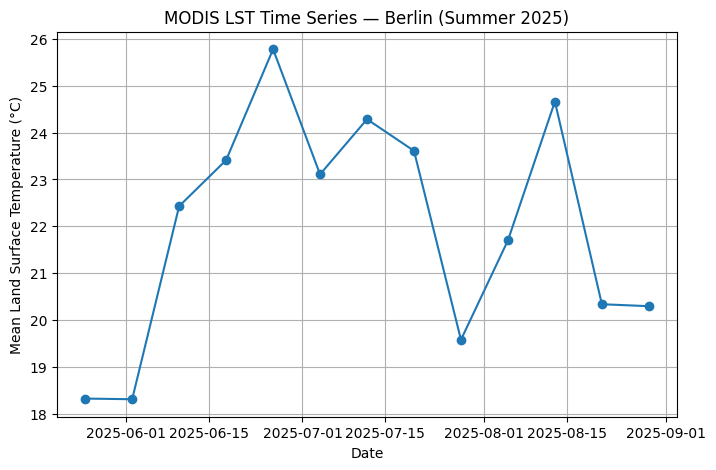

In [19]:
#  Example Computing Temporal UHI Trend for Berlin
import os
import numpy as np
import matplotlib.pyplot as plt

from pyhdf.SD import SD, SDC

# Step 1: Read all MODIS files
data_dir = "modis_lst"

files = sorted([f for f in os.listdir(data_dir) if f.endswith(".hdf")])

print("Number of files:", len(files))
print(files[:3])

# Step 3 — Extract LST and build time series
lst_timeseries = []
dates = []

for f in files:
    
    file_path = os.path.join(data_dir, f)

    # open MODIS file
    hdf = SD(file_path, SDC.READ)

    # extract LST layer
    lst_dataset = hdf.select("LST_Day_1km")
    lst_raw = lst_dataset.get().astype(float)

    # mask invalid values
    lst_raw[lst_raw == 0] = np.nan

    # convert to Celsius
    lst_c = lst_raw * 0.02 - 273.15

    # compute mean temperature
    mean_temp = np.nanmean(lst_c)

    lst_timeseries.append(mean_temp)

    # extract date from filename
    year = int(f.split(".")[1][1:5])
    day_of_year = int(f.split(".")[1][5:])

    date = np.datetime64(f"{year}-01-01") + np.timedelta64(day_of_year - 1, 'D')
    dates.append(date)

lst_timeseries = np.array(lst_timeseries)


plt.figure(figsize=(8,5))

plt.plot(dates, lst_timeseries, marker='o')

plt.xlabel("Date")
plt.ylabel("Mean Land Surface Temperature (°C)")
plt.title("MODIS LST Time Series — Berlin (Summer 2025)")

plt.grid(True)

plt.show()

In [17]:
# Example EDGAR GHG by sector and country which could be useful for assignment
import pandas as pd

file = "EDGAR_2025_GHG_booklet_2025.xlsx"

xls = pd.ExcelFile(file)

# Check what sheets exist in the Excel file
print(xls.sheet_names)

df = pd.read_excel(file, sheet_name="GHG_by_sector_and_country")
df.head()

['info', 'Citations and references', 'GHG_totals_by_country', 'GHG_by_sector_and_country', 'GHG_per_GDP_by_country', 'GHG_per_capita_by_country', 'LULUCF_macroregions', 'LULUCF_countries']


,Substance,Sector,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CO2,Agriculture,AFG,Afghanistan,0.029229,0.029229,0.029229,0.029229,0.039967,0.045310,...,0.116967,0.163009,0.311300,0.161333,0.151276,0.064795,0.040490,0.053114,0.052360,0.051832
1,CO2,Agriculture,ALB,Albania,0.113300,0.113300,0.113300,0.113300,0.113614,0.112514,...,0.056519,0.047405,0.054162,0.046462,0.066419,0.060552,0.048348,0.060657,0.061956,0.063322
2,CO2,Agriculture,ARG,Argentina,0.104343,0.104343,0.104343,0.104343,0.087214,0.077314,...,0.892257,1.385790,1.278409,1.592119,1.703062,1.925471,2.071404,1.941500,2.038488,2.154144
3,CO2,Agriculture,ARM,Armenia,0.055288,0.055288,0.055288,0.055288,0.059966,0.059966,...,0.033943,0.039443,0.052486,0.051071,0.061024,0.055838,0.044629,0.041800,0.041989,0.042187
4,CO2,Agriculture,AUS,Australia,0.311143,0.311143,0.311143,0.311143,0.311143,0.268190,...,2.324928,2.542624,2.949833,2.130700,2.275585,2.664304,3.253852,2.862671,2.810286,2.791744


# Acessing dataset: Our World in Data (OWID)

The **Our World in Data climate dataset** compiles data from multiple international sources, including:
- World Bank
- International Energy Agency
- Global Carbon Project

Website: https://ourworldindata.org

The dataset includes indicators such as:
- CO₂ emissions
- energy consumption
- population
- GDP
- energy intensity

These indicators allow analysis using the Kaya Identity.

We can load the Our World in Data (OWID) dataset containing population, GDP, energy consumption, and CO₂ emissions directly from this GitHub repository: https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv

In [18]:
# Load Dataset 
import pandas as pd

df = pd.read_csv("owid-energy-data.csv")

df.tail()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
23227,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,NaN,0.0,0.0,0.0,6.440,...,0.298,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23228,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,NaN,0.0,0.0,0.0,6.963,...,0.233,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23229,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,NaN,0.0,0.0,0.0,6.845,...,0.336,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23230,Zimbabwe,2023,ZWE,16340829.0,NaN,NaN,0.0,0.0,0.0,7.344,...,0.361,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23231,Zimbabwe,2024,ZWE,16634366.0,NaN,NaN,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
